# Day 44: Hierarchical Clustering - Agglomerative and Divisive

---

## Objective

---

    Understand and Implement Hirarchical Clustering, focusing on Agglomerative Clustering. Explore Tree-based clustering and Dendograms using a real-world dataset.

---

## Dataset

---

- **Dataset**: Iris Dataset (`sklearn.datasets.load_iris`)
- **Features**: Sepal length, sepal width, petal length, petal width
- **Target**: Iris species (for reference only, unsupervised learning used)

---

In [16]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
# Load DataSet
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

## EDA

---

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df.shape

(150, 5)

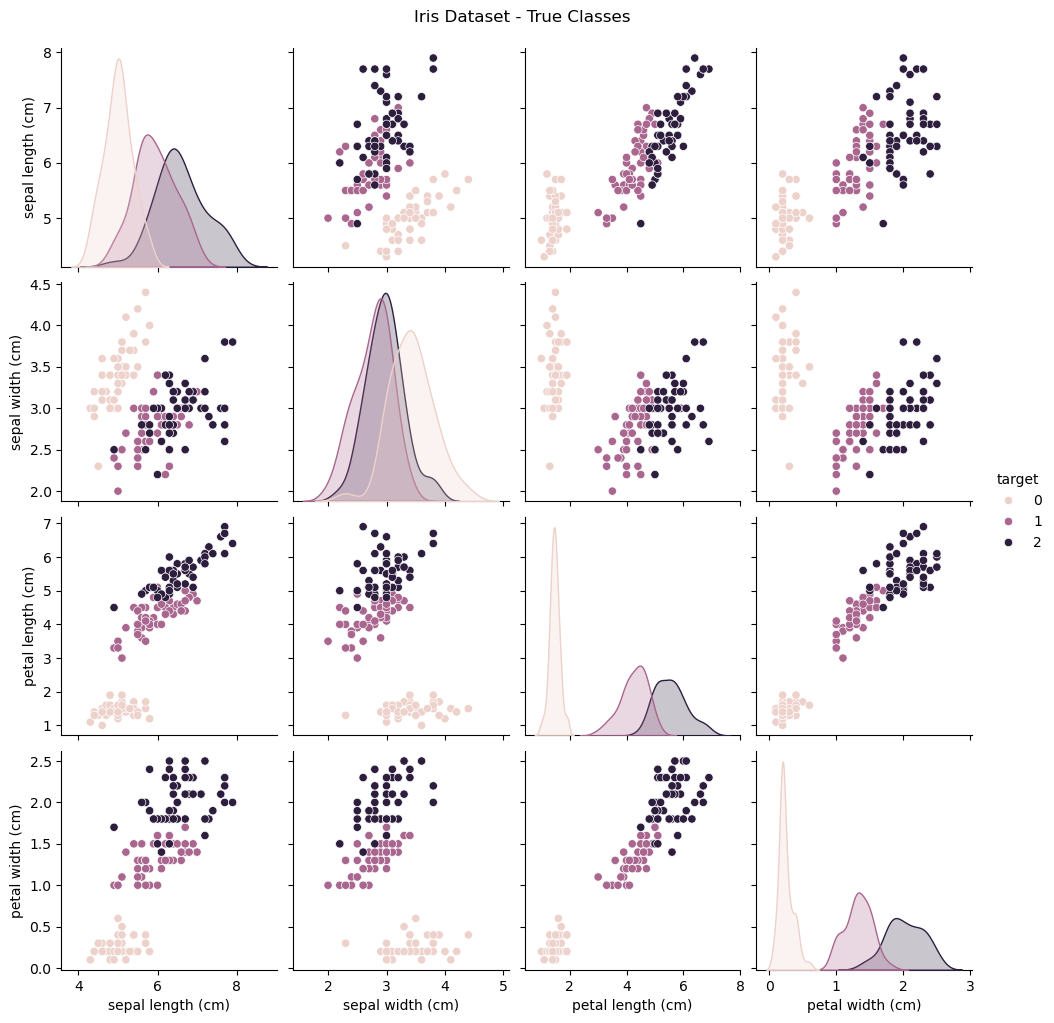

In [7]:
sns.pairplot(df, hue='target')
plt.suptitle('Iris Dataset - True Classes', y=1.02)
plt.show()

In [8]:
# Standardized the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.iloc[:, :-1])

In [9]:
#Create a linkage matrix
linked = linkage(X_scaled, method='ward')

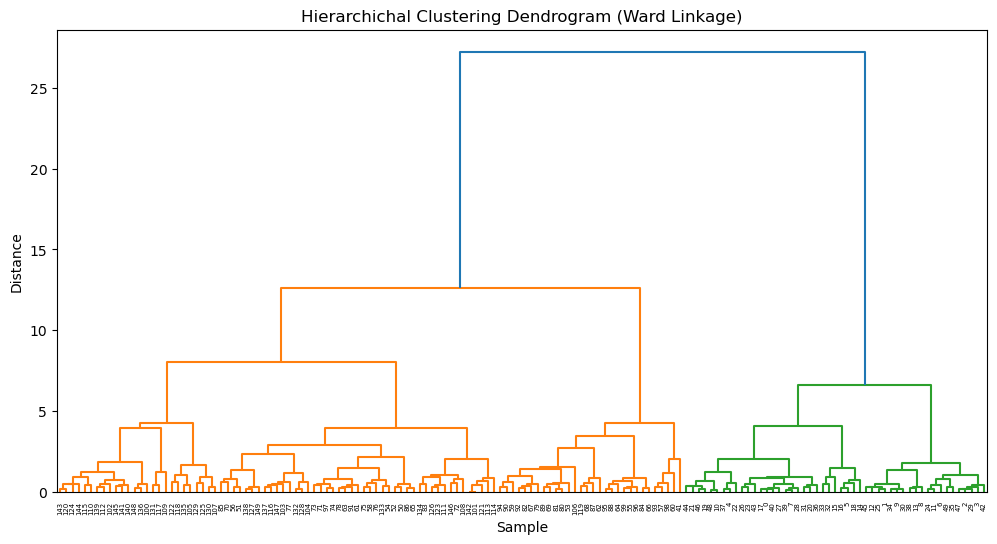

In [10]:
#Plot Dendrogram
plt.figure(figsize=(12,6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False)

plt.title('Hierarchichal Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample')
plt.ylabel('Distance')
plt.show()

In [11]:
# Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
preds = agg.fit_predict(X_scaled)
df['agg_cluster'] = preds

In [12]:
#Evaluate
score = silhouette_score(X_scaled, preds)
print(f'Silhouette Score (Agglomerative): {score:.2f}')

Silhouette Score (Agglomerative): 0.45


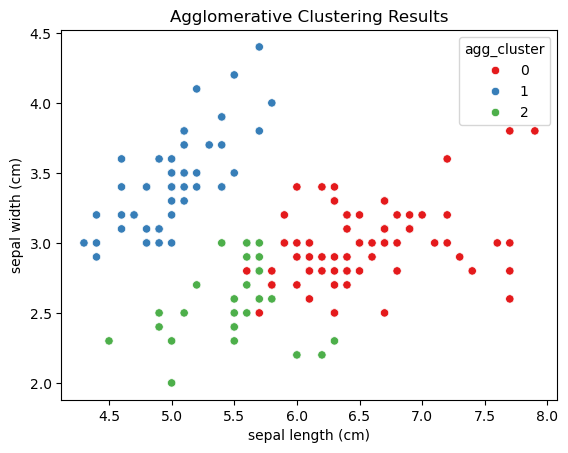

In [15]:
# Visualization Cluster Results
sns.scatterplot(data=df,
                x=iris.feature_names[0],
                y=iris.feature_names[1], 
                hue='agg_cluster', 
                palette='Set1')
plt.title('Agglomerative Clustering Results')
plt.show()

In [20]:
# Divisive Clustering
def divisive_clustering(X, max_clusters=4):
    cluster_labels = np.zeros(X.shape[0], dtype=int)
    clusters = {0:np.arange(X.shape[0])}
    next_label = 1

    while len(clusters) < max_clusters:
        #Find cluster with max size to split
        to_split = max(clusters, key=lambda k:len(clusters[k]))
        indices = clusters[to_split]
        if len(indices) <= 1:
            break

        #Apply KMeans 
        km = KMeans(n_clusters=2, random_state=42)
        split_labels = km.fit_predict(X[indices])

        #Update the clusters
        del clusters[to_split]
        clusters[to_split] = indices[split_labels == 0]
        clusters[next_label] = indices[split_labels == 1]
        next_label += 1


    #final label
    for label, idx in clusters.items():
        cluster_labels[idx] = label

    return cluster_labels

In [21]:
labels = divisive_clustering(X_scaled, max_clusters=3)

C:\Users\francis\Desktop\machinelearning_project\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\francis\Desktop\machinelearning_project\env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


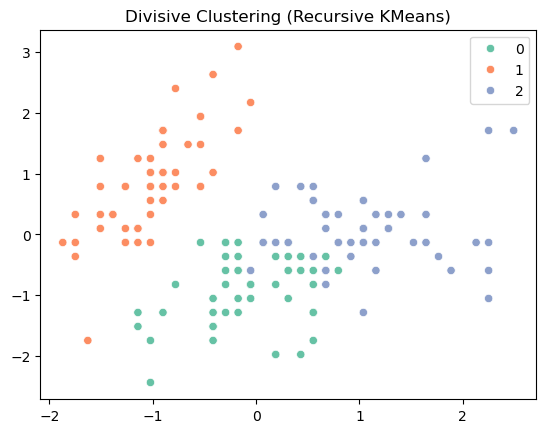

In [22]:
sns.scatterplot(x=X_scaled[:,0],
                y=X_scaled[:, 1],
                hue=labels,
                palette='Set2')
plt.title('Divisive Clustering (Recursive KMeans)')
plt.show()

## Conclusion
- Hierarchical Clustering builds a tree-like structure of clusters.
- Agglomerative Clustering (bottom-up) is commonly used and supported.
- Dendrograms are a powerful way to visualize the merge distances and cluster hierarchy.
- We used the Iris dataset and achieved a strong silhouette score, aligning well with actual species.
- Divisive clustering is less common but theoretically useful for some domains.